# Exploration of datasets
## PAN 2023

In [1]:
import os, sys
from nltk.stem.snowball import SnowballStemmer
import numpy as np
import pandas as pd
sys.path.append(os.path.abspath(".."))
from genai_detection.detectors.impostor import ImpostorDetector
from genai_detection.visualization import datasets

In [2]:
pan23 = datasets.Pan23Visualization()
ds_pan = pan23.load_dataset()
labels = ds_pan['same']
display(ds_pan.head())

,id,discourse_types,pair,same,authors
0,a0e656a3-955e-44f6-b5b3-dfd6e360a962,"[email, speech_transcription]",[I think I have decided with regards to the <t...,True,"[en_7, en_7]"
1,c42efa75-f418-4fac-80ca-4d0982704d25,"[email, speech_transcription]","[Dear <addr10_NN>, <nl><nl>If I was to go with...",True,"[en_31, en_31]"
2,a3a6745f-af62-4889-af49-93ec88594142,"[interview, email]","[So, erm, so I’m, erm, I’m actually from <cou...",True,"[en_88, en_88]"
3,244235f3-4647-4ed3-b078-60a2ea2850b7,"[email, speech_transcription]","[Hi <addr2_FN><nl><nl>This is my picture, that...",False,"[en_27, en_38]"
4,d410b3f0-b331-48ab-a524-c29ed1d487a2,"[interview, email]","[Oh, okay. Erm, well, I think of myself as kin...",False,"[en_87, en_32]"


In [3]:
labels.value_counts()

same
True     9246
False    9246
Name: count, dtype: int64

In [4]:
pan20 = datasets.Pan20Visualization()
ds_pan20 = pan20.load_dataset()
labels_pan20 = ds_pan20['same']
display(ds_pan20.head())

,id,fandoms,pair,same,authors
0,6cced668-6e51-5212-873c-717f2bc91ce6,"[Guardians of Ga'Hoole, Hetalia - Axis Powers]","[I shift a bit, warily letting my eyes dart fr...",True,"[1446633, 1446633]"
1,3c6c188a-db28-59aa-8c09-3d0f799ff579,"[Guardians of Ga'Hoole, Warriors]","[I shift a bit, warily letting my eyes dart fr...",True,"[1446633, 1446633]"
2,b0cfa94f-c9ec-5aa5-8331-a5a249b664cf,"[Guardians of Ga'Hoole, Xiaolin Showdown]",[A single tear escaped me as I left. I did hav...,True,"[1446633, 1446633]"
3,e6e86e73-9a7b-58f2-a652-a17b4a1bcabf,"[Hetalia - Axis Powers, Warriors]","[""Ja."" Ludwig kept his gaze upon her, solidly....",True,"[1446633, 1446633]"
4,4fe541af-912e-5a86-81a5-94c6d3891509,"[Hetalia - Axis Powers, Xiaolin Showdown]","[And he did. Slowly, hesitantly...but coming f...",True,"[1446633, 1446633]"


In [5]:
labels_pan20.value_counts()

same
True     35620
False    31292
Name: count, dtype: int64

In [6]:
pan20.dataset_stats()

,dataset,num_pairs,num_authors,num_same_pairs,num_different_pairs,avg_text_len,min_text_len,max_text_len,std_text_len,median_text_len
0,pan20,66912,52778,35620,31292,21435.528343,20670,296887,2685.487659,21284.0


In [7]:
authors = ds_pan['authors'].tolist()
authors = [s for item in authors for s in item.flatten().tolist() if isinstance(item, np.ndarray)]

pairs = ds_pan['pair'].tolist()
texts = [s for item in pairs for s in item.flatten().tolist() if isinstance(item, np.ndarray)]

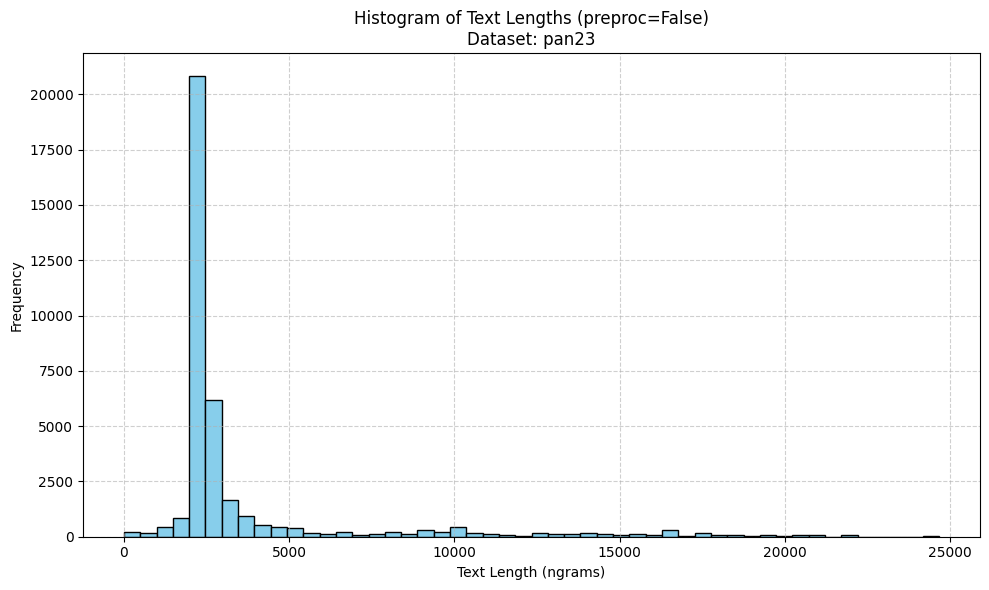

Average length (characters) per text: 3562.15


In [8]:
pan23.plot_text_length_histogram(bins=50)

In [9]:
def normalize_text(text):
    stemmer = SnowballStemmer('english')
    return ' '.join(stemmer.stem(w) for w in text.lower().split())

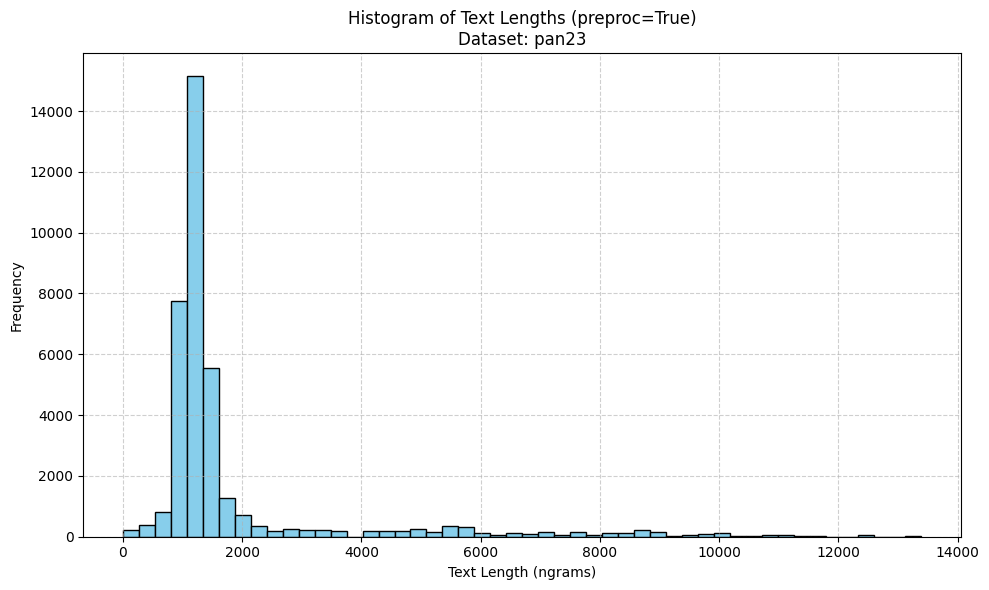

Average length (characters) per text: 1853.42


In [10]:
from functools import partial


impostor_det = ImpostorDetector(ds_pan, top_n=250, portion_delete=0.5, shared_vocab_only=True)

preproc_fn = partial(impostor_det.tokenize_char_ngrams, n=4, normalize_ws=True, space_free=True)
pan23.plot_text_length_histogram(bins=50, preprocess_fn=preproc_fn)

In [11]:
# df_auth_text = pd.DataFrame({'author':authors, 'text':texts})

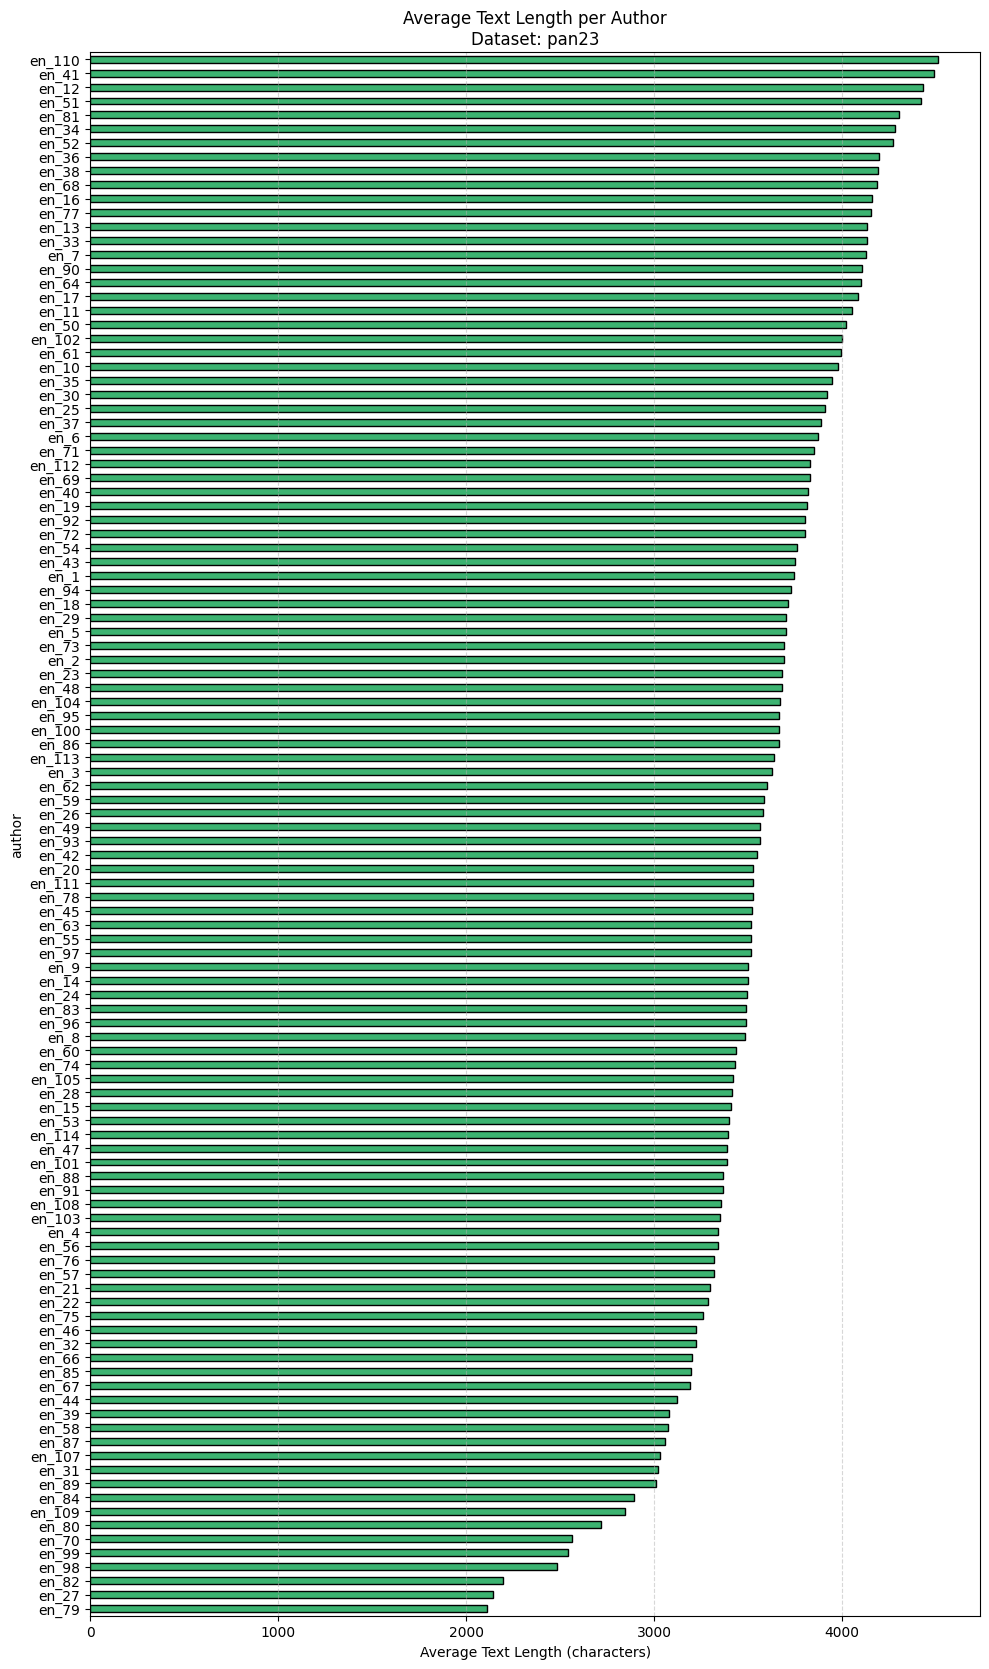

In [12]:
pan23.plot_avg_text_length_per_author()

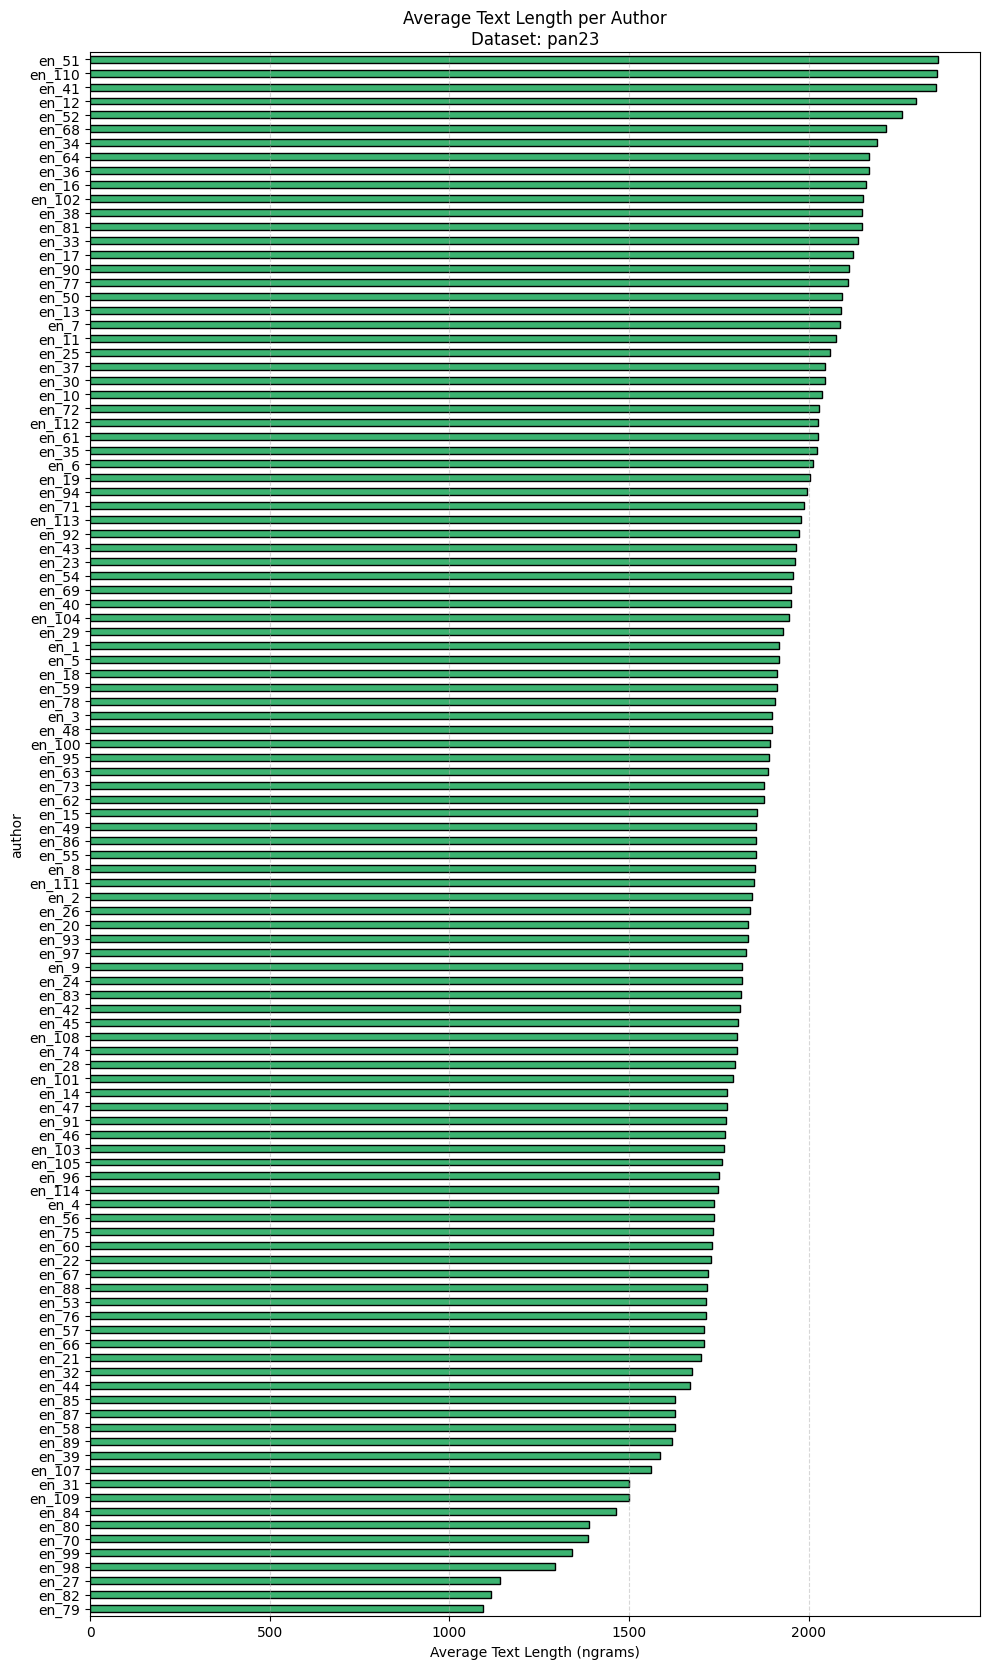

In [13]:
pan23.plot_avg_text_length_per_author(unit='ngrams')

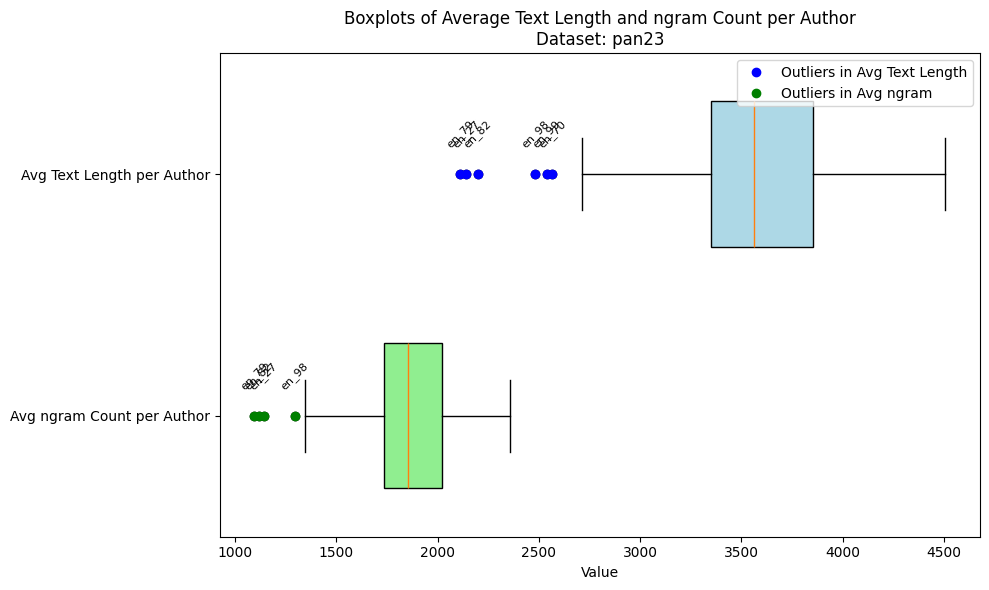

In [14]:
pan23.boxplots_text_len_ngrams()